In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import norm
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform

# **Function 8** — 8D Black-Box Optimisation

Optimising an eight-dimensional black-box function representing e.g. ML model validation accuracy across eight hyperparameters.

- **Optimisation Goal:** Maximise
- **Input:** 8D
- **All-time best:** 9.951 at [0.111, 0.167, 0.129, 0.229, 0.996, 0.475, 0.302, 0.476] (Week 3)

In [3]:
# Load current cumulative dataset (original + prior weekly updates) for Function 8
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy')

# New data for Week 9 (Function 8)
X_w8_new_point = np.array([0.014565, 0.233424, 0.156410, 0.215734, 0.993571, 0.163832, 0.082661, 0.956290], dtype=np.float64)
Y_w8_new_point = np.array([9.8000538062215], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w8_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w8_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_8/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 8: ", X_unique)
print("Updated Outputs (Y) - Function 8: ", Y_updated)

Updated Inputs (X) - Function 8:  [[0.007838   0.337307   0.164679   0.407388   0.632409   0.551169
  0.306982   0.5023    ]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.014565   0.233424   0.15641    0.215734   0.993571   0.163832
  0.082661   0.95629   ]
 [0.02894663 0.02827906 0.48137155 0.6131746  0.67266045 0.02211341
  0.6014833  0.52488505]
 [0.029788   0.370437   0.009211   0.56322    0.914458   0.813905
  0.149129   0.554138  ]
 [0.0417     0.167136   0.185989   0.004377   0.961301   0.357272
  0.961301   0.357272  ]
 [0.04432925 0.01358149 0.25819824 0.57764416 0.05127992 0.15856307
  0.59103012 0.07795293]
 [0.05644741 0.06595555 0.02292868 0.03878647 0.40393544 0.80105533
  0.48830701 0.89308498]
 [0.097603   0.135405   0.156089   0.022873   0.887585   0.187209
  0.032006   0.53162   ]
 [0.110613   0.166799   0.129222   0.228937   0.996353   0.475272
  0.30197    0.476277  ]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.

## **Output Analysis**

- **Comparison**: Week 8 returned 9.800 at [0.015, 0.233, 0.156, 0.216, 0.994, 0.164, 0.083, 0.956]. 
    - This is a strong, stable result, very close to the all-time best of 9.951 achieved in Week 3.

- **Real-World Implications**: In a high-dimensional black-box (like a complex aerospace simulation or a massive neural network), finding a region that consistently yields 9.8+ across 8 different variables is rare. 
    - I have found a high-altitude plateau of performance.

- **Model Clues**: The 8D space is massive, making it nearly impossible to map entirely. 
    - However, the model has identified that the "sweet spot" requires $x_1$ and $x_3$ to stay very low ($<0.15$) while $x_5$ and $x_8$ remain very high ($>0.90$).

- **Key Changes for W9**: Since I am already at 9.8/10.0, I am moving from exploration to Local Refinement. 
    - I will decrease the exploration weight ($\beta$) and focus 75% of the computational budget on a very tight radius around the Week 3 and Week 8 successes.

## **Bayesian Optimisation**

- **Model**: Gaussian Process Regressor with Matern (nu=2.5) + WhiteKernel and Yeo-Johnson transformation.

    - **Reasoning**: In 8D, the volume of the space is so large that the GP can easily become overwhelmed by noise. 
        - The Matern kernel provides the necessary structural rigidity to prevent the model from over-fitting to random fluctuations in the 9.80–9.95 range.

- **Changes for Week 9**: I am increasing the n_restarts_optimizer to 25.

- **Intended Impact**: To ensure the GP finds the global maximum of its own internal marginal likelihood, providing the most accurate "map" possible for the final 8D coordinates.

In [4]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

# 3. Fit Model
kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)

model.fit(X_unique, Y_transformed)

/Users/prathamyeole/Library/Python/3.13/lib/python/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**: Balanced UCB 
- **Strategy**: Upper Confidence Bound (UCB) with $\beta=2.0$.
    - **Reasoning**: In 8D, I cannot be purely greedy (EI) because there could still be a slightly higher peak just a few units away in a dimension I haven't tweaked. 
        - A $\beta$ of 2.0 allows the model to look at points that have a high average predicted value but still possess a small amount of discovery potential.

- Key Changes: I am generating a focused grid with a standard deviation of 0.02 around the Week 3 all-time best.
    - I use a 75/25 focused-to-uniform split.

In [5]:
def upper_confidence_bound(X, model, beta=2.0):
    mu, sigma = model.predict(X, return_std=True)
    return mu + beta * sigma

# 5. Grid Generation centered on W3 Best
w3_best = np.array([0.110613, 0.166799, 0.129222, 0.228937, 0.996353, 0.475272, 0.301970, 0.476277])
x_focused = np.random.normal(loc=w3_best, scale=0.02, size=(7500, 8))
x_uniform = np.random.uniform(0, 1, size=(2500, 8))
x_grid = np.vstack([x_focused, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

# 6. Selection
ucb_values = upper_confidence_bound(x_grid, model, beta=2.0)
next_query = x_grid[np.argmax(ucb_values)]

print(f"Next Query Point (F8): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}-{next_query[5]:.6f}-{next_query[6]:.6f}-{next_query[7]:.6f}")

Next Query Point (F8): 0.263413-0.077268-0.022492-0.179458-0.852835-0.318308-0.139938-0.482812


## **Visualisation**

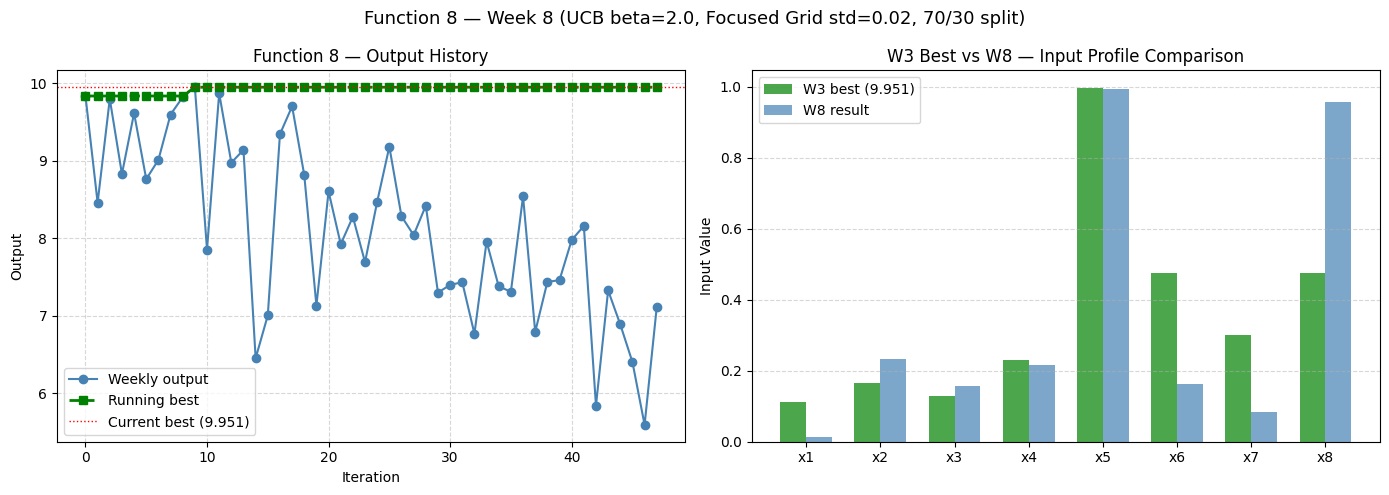

In [7]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(np.max(Y_updated), color='red', linestyle=':', linewidth=1, label=f'Current best ({np.max(Y_updated):.3f})')
axes[0].set_title('Function 8 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Compare W3 best vs W7 input profiles
dim_labels = [f'x{i+1}' for i in range(8)]
x_pos = np.arange(8)
width = 0.35
axes[1].bar(x_pos - width/2, w3_best, width, label='W3 best (9.951)', color='green', alpha=0.7)
axes[1].bar(x_pos + width/2, X_w8_new_point, width, label='W8 result', color='steelblue', alpha=0.7)
axes[1].set_title('W3 Best vs W8 — Input Profile Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(dim_labels)
axes[1].set_ylabel('Input Value')
axes[1].legend()
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Function 8 — Week 8 (UCB beta=2.0, Focused Grid std=0.02, 70/30 split)', fontsize=13)
plt.tight_layout()
plt.show()